## Supplementary Figure 5

Note: This notebook requires the following simulation outputs (see `simulations.md` for run commands):

- `out/supp_fig5_pv_som_vip/`: E/PV/SOM/VIP circuit, 5 seeds
- `out/supp_fig5_sweep_g_{sompv,somvip,evip,epv}/`: connection-strength sweeps, 3 seeds per value

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import sys
from functools import partial
from pathlib import Path

import numpy as np
import jax
import jax.numpy as jnp
from diffrax import diffeqsolve, ODETerm, SaveAt, Euler, ConstantStepSize

import matplotlib as mpl
import matplotlib.pyplot as plt
import spiffyplots
from spiffyplots import MultiPanel
from matplotlib.colors import to_rgba
from cmcrameri import cm as cmc

mpl.style.use('spiffy')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",})
mpl.rc('text.latex', preamble=r'\usepackage{cmbright}')

from bcp.analysis import HydraRunOutput, HydraMultirun, rebuild_traj_run

repo_root = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "bcp").is_dir())
sys.path.insert(0, str(repo_root))
from run_traj import SimulationRunner

#### Directory setup

In [2]:
run_dir = repo_root / "out" / "supp_fig5_pv_som_vip"
shapes_dir = repo_root / "data" / "shapes"

sfig5_dir = repo_root / "figures" / "supp_fig5"
sfig5_dir.mkdir(parents=True, exist_ok=True)

#### Plotting parameters

In [3]:
cm = 1 / 2.54

singlecolwidth = 8.5 * cm
onehalfcolwidth = 11.4 * cm
doublecolwidth = 17.4 * cm

color_exc = '#CD2027'
color_som = '#0077B8'
color_pv = '#57CAF1'
color_vip = "#a577ed"
color_inputs = '#808285'
color_openloop = 'gray'
color_closedloop = '#F49F1E'
color_target = 'black'
color_accent = 'black'
color_shading = 'gray'

linewidth = 1.0

### Panels e-g: training performance

In [4]:
figsize_perf = (14*cm, 3*cm)
xticks_time = [0, 360, 720]

In [5]:
table = HydraMultirun(run_dir, result_files=['results.pkl']).table(
    keys=['OL_R2', 'CL_error', 'OL_loss', 'training_time'])
X_TRAINING = table['training_time'][0]

R2 = np.stack(table['OL_R2'])
FB = np.abs(np.stack(table['CL_error'])).mean(-1)
LOSS = np.stack(table['OL_loss'])
print("Final R2:", R2[:, -1].mean())

Final R2: 0.984013843536377


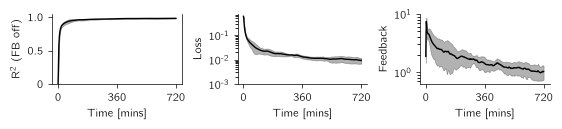

In [6]:
fig = MultiPanel(grid=[3], figsize=figsize_perf, width_ratios=[1, 1, 1])

for ax, data in zip(fig.panels, [R2, LOSS, FB]):
    ax.plot(X_TRAINING, data.mean(0), color='black', lw=linewidth)
    ax.fill_between(X_TRAINING, data.mean(0) - data.std(0), data.mean(0) + data.std(0), color='black', alpha=0.3)
    ax.set_xlabel('Time [mins]')
    ax.set_xticks(xticks_time)
    ax.set_xticklabels(xticks_time)

ax = fig.panels[0]
ax.set_ylim(1e-1, 1.05)
ax.spines['right'].set_visible(True)
ax.set_ylabel(r'$R^2$ (FB off)', fontsize=8)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels([0, 0.5, 1.0])

ax = fig.panels[1]
ax.set_ylabel(r'Loss', fontsize=8)
ax.set_yscale('log')
ax.set_yticks([1e-3, 1e-2, 1e-1])
ax.set_yticklabels([r'10\textsuperscript{-3}', r'10\textsuperscript{-2}', r'10\textsuperscript{-1}'])

ax = fig.panels[2]
ax.set_ylabel(r'Feedback', fontsize=8)
ax.set_yscale('log')
ax.set_yticks([1e0, 1e1])
ax.set_yticklabels([r'10\textsuperscript{0}', r'10\textsuperscript{1}'])

plt.savefig(sfig5_dir / 'e-g_performance.pdf', bbox_inches='tight')
plt.show()

### Panel i: robustness to connection strengths

In [7]:
sweep_specs = [
    {"folder": "supp_fig5_sweep_g_sompv", "key": "g_SOMPV",
     "xlabel": r"$g_{\mathrm{SOM}\to\mathrm{PV}}$ [a.u.]"},
    {"folder": "supp_fig5_sweep_g_somvip", "key": "g_SOMVIP",
     "xlabel": r"$g_{\mathrm{SOM}\to\mathrm{VIP}}$ [a.u.]",
     "unstable_from": 0.45, "xlim": (0.0, 1.0), "xticks": (0.0, 0.2, 0.4, 0.6, 0.8, 1.0)},
    {"folder": "supp_fig5_sweep_g_evip", "key": "g_EVIP",
     "xlabel": r"$g_{\mathrm{E}\to\mathrm{VIP}}$ [a.u.]"},
    {"folder": "supp_fig5_sweep_g_epv", "key": "g_EPV",
     "xlabel": r"$g_{\mathrm{E}\to\mathrm{PV}}$ [a.u.]"},
]
metrics = ("OL_R2", "OL_loss")
figsize_sweeps = (doublecolwidth, 6*cm)
ylim_sweep_R2 = (0.9, 1.0)
loss_ticks = [3e-3, 1e-2, 3e-2]
loss_ticklabels = ["0.003", "0.01", "0.03"]

In [8]:
sweeps = {}
for spec in sweep_specs:
    runs = HydraMultirun(repo_root / "out" / spec["folder"], result_files=['results.pkl'])
    values = np.unique([float(run.config.model[spec["key"]]) for run in runs])
    seeds = np.unique([int(run.config.seed) for run in runs])
    final = {m: np.full((seeds.size, values.size), np.nan) for m in metrics}  # [seeds, values]
    for run in runs:
        i = np.flatnonzero(seeds == int(run.config.seed)).item()
        j = np.flatnonzero(np.isclose(values, float(run.config.model[spec["key"]]))).item()
        results = run.results
        for m in metrics:
            final[m][i, j] = results[m][-1]
    assert all(np.isfinite(f).all() for f in final.values()), spec["folder"]
    sweeps[spec["key"]] = {"values": values, "final": final}
    print(spec["key"], values, f"n={seeds.size}")

g_SOMPV [0.   0.25 0.5  0.75 1.  ] n=3
g_SOMVIP [0.  0.2 0.4] n=3
g_EVIP [0.  0.5 1.  1.5 2. ] n=3
g_EPV [0.  0.5 1.  1.5 2. ] n=3


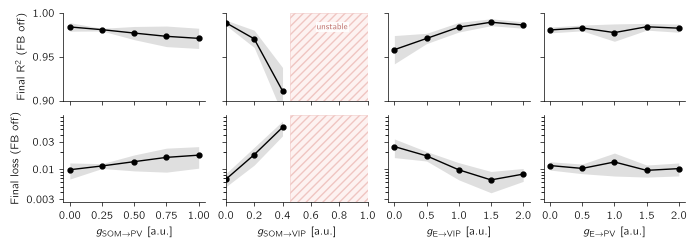

In [9]:
loss_all = np.concatenate([s["final"]["OL_loss"].ravel() for s in sweeps.values()])
loss_limits = (loss_all.min() * 0.75, loss_all.max() * 1.25)

fig = MultiPanel(grid=[4, 4], figsize=figsize_sweeps, width_ratios=[1, 1, 1, 1],
                 height_ratios=[1, 1], hspace=0.0)

for row, metric in enumerate(metrics):
    for col, spec in enumerate(sweep_specs):
        ax = fig.panels[row * len(sweep_specs) + col]
        values = sweeps[spec["key"]]["values"]
        final = sweeps[spec["key"]]["final"][metric]
        mean, std = final.mean(0), final.std(0)

        xlim = spec.get("xlim", (values[0] - 0.05 * values[-1], values[-1] + 0.05 * values[-1]))
        if "unstable_from" in spec:
            ax.axvspan(spec["unstable_from"], xlim[1], facecolor="#FDE8E7", edgecolor="#E5A09B",
                       hatch="////", alpha=0.55, linewidth=0.4, zorder=0)
            if row == 0:
                ax.text(0.75, 0.88, "unstable", transform=ax.transAxes, color="#B45B55", fontsize=6,
                        ha="center", va="top",
                        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.9, "pad": 0.8})

        ax.plot(values, mean, color=color_accent, marker="o", ms=3.5, lw=linewidth, zorder=3)
        lower = np.maximum(mean - std, np.finfo(float).tiny) if metric == "OL_loss" else mean - std
        ax.fill_between(values, lower, mean + std, color=color_shading, alpha=0.25, linewidth=0)
        ax.set_xlim(*xlim)
        ax.set_xticks(spec.get("xticks", values))

        if metric == "OL_R2":
            ax.set_ylim(*ylim_sweep_R2)
            ax.tick_params(axis="x", labelbottom=False)
        else:
            ax.set_yscale("log")
            ax.set_ylim(*loss_limits)
            ax.set_yticks(loss_ticks)
            ax.set_yticklabels(loss_ticklabels)
            ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
            ax.set_xlabel(spec["xlabel"])
        if col > 0:
            ax.tick_params(axis="y", labelleft=False)

fig.panels[0].set_ylabel(r"Final $R^2$ (FB off)")
fig.panels[4].set_ylabel("Final loss (FB off)")

plt.savefig(sfig5_dir / "i_parameter_sweeps.pdf", bbox_inches="tight")
plt.show()

### Panels b-d, h: activity of an untrained circuit and output after training

In [10]:
EXAMPLE_SEED = 1
ACTIVITY_KP = 50
TRACE_ASSEMBLY = 1
LEARNED_KEYS = ("W_FF_E", "W_FF_I", "W_OUT", "B")
figsize_activity = (10*cm, 5.5*cm)
figsize_traj = (3*cm, 3*cm)

In [11]:
example_run = HydraRunOutput(run_dir / f"seed{EXAMPLE_SEED}")
cfg, task, vectorfield = rebuild_traj_run(example_run, shapes_dir, jax_threefry_partitionable=True)
final_state = example_run.load_pickle('final_state.pkl')

vectorfield.controller.k_p = ACTIVITY_KP
vectorfield.controller.k_i = 0
sim = SimulationRunner(vectorfield, Euler(), ConstantStepSize(), cfg.dt, cfg.rec_dt, cfg.T)

x_burn, _, x_burn_interp, _ = task.simulate()
x, y, x_interp, y_interp = task.simulate()


def burn_in_and_record(state):
    burn_state, _ = sim(state, x_burn_interp)
    _, OL_sol = sim(dict(burn_state), x_interp)
    _, CL_sol = sim.closedloop(dict(burn_state), x_interp, y_interp)
    return (OL_sol, vectorfield.analyze_run(x, OL_sol, cfg.dt, cfg.rec_dt, y, closedloop=False),
            vectorfield.analyze_run(x, CL_sol, cfg.dt, cfg.rec_dt, y, closedloop=True))


# untrained circuit; the published panels draw W_FF_E and W_OUT from key_init
# directly, not from the training run's initialization
_, _, key_init, _ = jax.random.split(jax.random.PRNGKey(int(cfg.seed)), 4)
OL_sol, OL_results, CL_results = burn_in_and_record(vectorfield.get_initial_state(rng_key=key_init))

# trained parameters in a fresh dynamic state
trained_state = vectorfield.get_initial_state()
trained_state.update({k: jnp.asarray(final_state[k]) for k in LEARNED_KEYS})
_, trained_OL_results, _ = burn_in_and_record(trained_state)

masks = {
    "E": np.asarray(vectorfield.M_E[:, TRACE_ASSEMBLY]) > 0,
    "SST": np.asarray(vectorfield.M_SOM[:, TRACE_ASSEMBLY]) > 0,
    "VIP": np.asarray(vectorfield.M_VIP[:, TRACE_ASSEMBLY]) > 0,
}
OL_assembly_error = np.asarray(OL_results["error_hidden"])[:, masks["E"]].mean(-1)
CL_assembly_error = np.asarray(CL_results["error_hidden"])[:, masks["E"]].mean(-1)

print(f"Untrained open-loop R2:   {float(OL_results['R2']):.3f}")
print(f"Untrained closed-loop R2: {float(CL_results['R2']):.3f}")
print(f"Trained open-loop R2:     {float(trained_OL_results['R2']):.3f}")

/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg
Untrained open-loop R2:   0.004
Untrained closed-loop R2: 0.036
Trained open-loop R2:     0.989


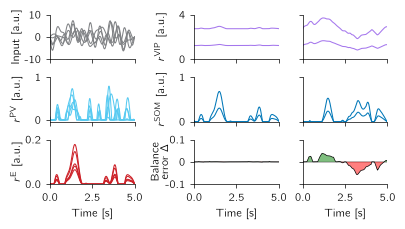

In [12]:
time = np.asarray(OL_sol.ts)
input_trace = np.asarray(x)[::int(round(cfg.rec_dt / cfg.dt))]
traces = {
    "input": input_trace[:, :5],
    "PV": np.asarray(OL_results["rPV"])[:, :5],
    "E": np.asarray(OL_results["rE"])[:, masks["E"]][:, :5],
    "OL_VIP": np.asarray(OL_results["rVIP"])[:, masks["VIP"]],
    "OL_SST": np.asarray(OL_results["rSOM"])[:, masks["SST"]],
    "CL_VIP": np.asarray(CL_results["rVIP"])[:, masks["VIP"]],
    "CL_SST": np.asarray(CL_results["rSOM"])[:, masks["SST"]],
}

fig = MultiPanel(grid=[3, 3, 3], figsize=figsize_activity, width_ratios=[1, 1, 1],
                 height_ratios=[1, 1, 1], wspace=0.0, hspace=0.0)
# MultiPanel rounds figsize to two decimal inches
plt.gcf().set_size_inches(*figsize_activity, forward=True)

# row-major: left column [0, 3, 6], open loop [1, 4, 7], closed loop [2, 5, 8]
trace_panels = [
    (0, "input", color_inputs, r"Input [a.u.]"),
    (3, "PV", color_pv, r"$r^{\mathrm{PV}}$ [a.u.]"),
    (6, "E", color_exc, r"$r^{\mathrm{E}}$ [a.u.]"),
    (1, "OL_VIP", color_vip, r"$r^{\mathrm{VIP}}$ [a.u.]"),
    (4, "OL_SST", color_som, r"$r^{\mathrm{SOM}}$ [a.u.]"),
    (2, "CL_VIP", color_vip, r"$r^{\mathrm{VIP}}$ [a.u.]"),
    (5, "CL_SST", color_som, r"$r^{\mathrm{SOM}}$ [a.u.]"),
]
plot_slice = slice(None, None, max(1, int(round(5e-3 / float(cfg.rec_dt)))))
plot_time = time[plot_slice]
ylabel_x = {0: -0.4, 1: -0.4}

for idx, key, color, label in trace_panels:
    ax = fig.panels[idx]
    ax.plot(plot_time, traces[key][plot_slice], color=color, lw=0.75, rasterized=True)
    if idx % 3 in ylabel_x:
        ax.set_ylabel(label, ha="center", va="center", fontsize=8)
        ax.yaxis.set_label_coords(ylabel_x[idx % 3], 0.5)
    ax.margins(x=0)

for idx, error in [(7, OL_assembly_error), (8, CL_assembly_error)]:
    ax = fig.panels[idx]
    error = error[plot_slice]
    ax.fill_between(plot_time, 0, error, where=error > 0, color="green", alpha=0.5, zorder=1, linewidth=0.0)
    ax.fill_between(plot_time, 0, error, where=error < 0, color="red", alpha=0.5, zorder=1, linewidth=0.0)
    ax.plot(plot_time, error, color=color_accent, lw=0.5, zorder=2)
    ax.axhline(0, color=color_accent, lw=0.35, zorder=0)
    if idx % 3 in ylabel_x:
        ax.set_ylabel("Balance\n" r"error $\Delta$", ha="center", va="center", fontsize=8)
        ax.yaxis.set_label_coords(ylabel_x[idx % 3], 0.5)
    ax.margins(x=0)

for ax in fig.panels:
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=2))
    ax.set_xlim(0, cfg.T)
# plain-string negative labels: the PDF backend lacks the Unicode minus in this font
fig.panels[0].set_ylim(-10, 10)
fig.panels[0].set_yticks([-10, 0, 10])
fig.panels[0].set_yticklabels(["-10", "0", "10"])
fig.panels[3].set_yticks([0, 1])
fig.panels[6].set_ylim(0, 0.2)
fig.panels[6].set_yticks([0, 0.2])
for idx in (1, 2):
    fig.panels[idx].set_ylim(0, 4)
    fig.panels[idx].set_yticks([0, 4])
for idx in (4, 5):
    fig.panels[idx].set_ylim(0, 1)
    fig.panels[idx].set_yticks([0, 1])
for idx in (7, 8):
    fig.panels[idx].set_ylim(-0.1, 0.1)
    fig.panels[idx].set_yticks([-0.1, 0, 0.1])
    fig.panels[idx].set_yticklabels(["-0.1", "0", "0.1"])
for idx in (2, 5, 8):
    fig.panels[idx].tick_params(axis="y", labelleft=False)
for idx in (0, 1, 2, 3, 4, 5):
    fig.panels[idx].tick_params(axis="x", labelbottom=False)
for idx in (6, 7, 8):
    fig.panels[idx].set_xlabel("Time [s]", fontsize=8)

plt.savefig(sfig5_dir / "b-d_activity.pdf", dpi=300)
plt.show()

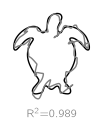

In [13]:
fig, ax = plt.subplots(1, 1, figsize=figsize_traj)
out = trained_OL_results['uOut']
target_traj = task.target.get_trajectory()
ax.plot(out[:, 0], out[:, 1], color=color_openloop, lw=linewidth)
ax.plot(target_traj[:, 0], target_traj[:, 1], color=color_target, lw=linewidth, zorder=-1)

ax.axis('off')
ax.set_aspect('equal', adjustable='box', anchor='SE')
ax.text(0.5, -0.05, rf"$R^2$={trained_OL_results['R2']:.3f}",
        fontsize=8, color=color_openloop, ha='center', va='top', transform=ax.transAxes)

plt.savefig(sfig5_dir / 'h_trajectory_after.pdf', bbox_inches='tight')
plt.show()